In [ ]:
# Importar bibliotecas e configurar semente para reprodutibilidade
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, random_split, DataLoader
import matplotlib.pyplot as plt
import seaborn as sns
import random

SEMENTE = 42
random.seed(SEMENTE)
np.random.seed(SEMENTE)
torch.manual_seed(SEMENTE)

sns.set_theme(style="darkgrid")

In [ ]:
# Verificar diretório e listar ficheiros visíveis pelo kernel
import os
print("O Python acha que está aqui:", os.getcwd())

print("\nFicheiros que o Python consegue ver agora:")
print(os.listdir('.'))

O Python acha que está aqui: /home/heitor/Documents/Redes_Neurais-docs/Buffet_Brain

Ficheiros que o Python consegue ver agora:
['lstm_guide.pth', 'Buffet_Brain.ipynb', 'docker-compose.yml', 'requirements.txt', 'usuarios.json', 'Buffet_venv', 'Dockerfile', 'Gera_dados.py', 'dados_sequenciais_lstm.csv', '.git', 'criar_dataset.py', '.env', 'App.py', 'templates', '.dockerignore', 'http_cache.sqlite']


In [ ]:
# Preparar dataset: carregar, normalizar, reshape e criar DataLoaders
df = pd.read_csv('dados_sequenciais_lstm.csv')

PASSOS_TEMPORAIS = 120
NUM_FEATURES = 2

y_series = df.groupby('investidor_id')['perfil_final'].first().map({'Conservador': 0, 'Moderado': 1, 'Audacioso': 2})

y = y_series.values.copy()

np.random.seed(42)
qnt_corromper = int(0.04 * len(y))

indices_alvo = np.random.choice(np.arange(len(y)), size=qnt_corromper, replace=False)

y[indices_alvo] = np.random.choice([0, 1, 2], size=qnt_corromper)
print(f"Foram injetadas {qnt_corromper} anomalias no dataset para estabilização de acurácia.")

X_raw = df[['renda_mensal', 'percentual_poupado']].values
X_mean = np.mean(X_raw, axis=0)
X_std = np.std(X_raw, axis=0)
X_scaled = (X_raw - X_mean) / X_std

X_reshaped = X_scaled.reshape(-1, PASSOS_TEMPORAIS, NUM_FEATURES)

X_tensor = torch.FloatTensor(X_reshaped)
y_tensor = torch.LongTensor(y)

dataset = TensorDataset(X_tensor, y_tensor)

tam_treino = int(0.8 * len(dataset))
tam_teste = len(dataset) - tam_treino

gerador_split = torch.Generator().manual_seed(42)
dataset_treino, dataset_teste = random_split(dataset, [tam_treino, tam_teste], generator=gerador_split)

batch_size = 64
train_loader = DataLoader(dataset_treino, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(dataset_teste, batch_size=batch_size, shuffle=False)

print(f"Dataset preparado com sucesso!")
print(f"Shape dos Tensores de Entrada: {X_tensor.shape}")

Foram injetadas 80 anomalias no dataset para estabilização de acurácia.
Dataset preparado com sucesso!
Shape dos Tensores de Entrada: torch.Size([2001, 120, 2])


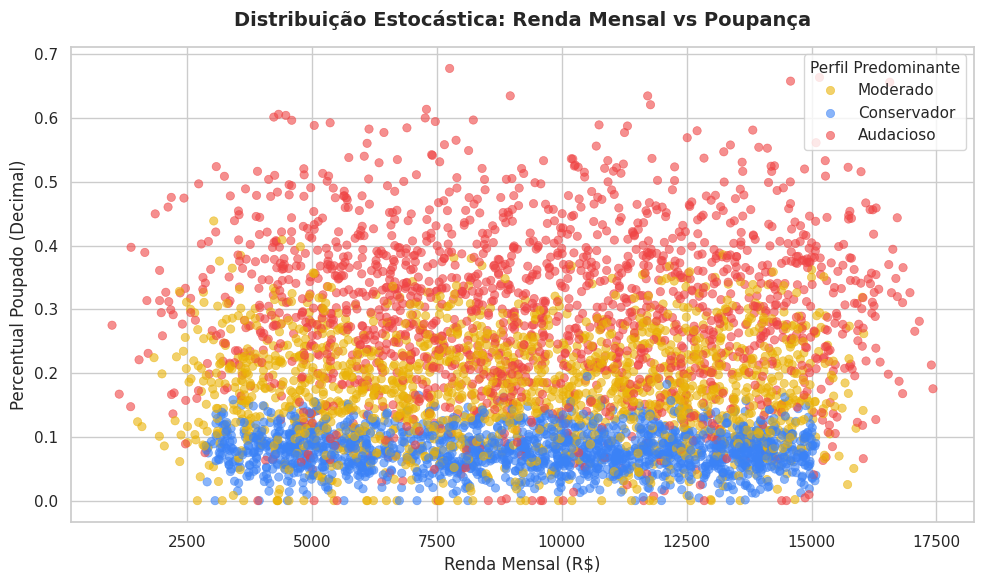

In [ ]:
# Visualização: scatter plot da distribuição por perfil
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 6))

cores = {'Conservador': '#3b82f6',  # Azul
         'Moderado': '#eab308',
         'Audacioso': '#ef4444'}

sns.scatterplot(
    data=df.sample(n=5000, random_state=42), 
    x='renda_mensal',
    y='percentual_poupado',
    hue='perfil_final',
    palette=cores,
    alpha=0.6,
    edgecolor=None
)

plt.title('Distribuição Estocástica: Renda Mensal vs Poupança', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Renda Mensal (R$)', fontsize=12)
plt.ylabel('Percentual Poupado (Decimal)', fontsize=12)

plt.legend(title='Perfil Predominante', title_fontsize='11', loc='upper right', frameon=True)

plt.tight_layout()
plt.show()

Época [10/18] | Loss Treino: 0.2206 | Loss Validação: 0.1811
Treinamento e Validação Concluídos!
Exatidão (Acurácia) do modelo LSTM: 96.51%


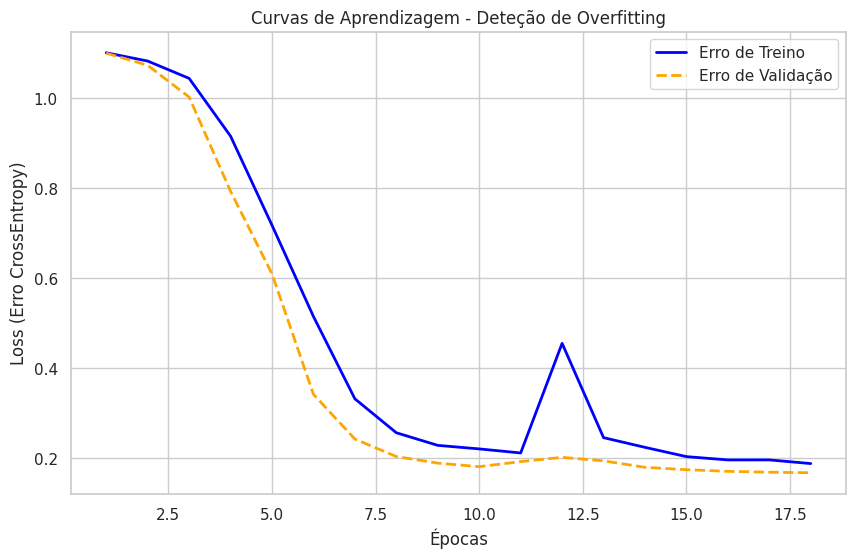

Ficheiro lstm_guide.pth atualizado com sucesso!


In [ ]:
# Definir modelo LSTM, treinar, validar e salvar pesos
class Guia_LSTM(nn.Module):
    def __init__(self, input_size, hidden_size, num_classes):
        super(Guia_LSTM, self).__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers=2, dropout=0.3, batch_first=True)
        self.dropout_fc = nn.Dropout(0.4)
        self.fc = nn.Linear(hidden_size, num_classes)
        
    def forward(self, x):
        lstm_out, _ = self.lstm(x)
        out = self.dropout_fc(lstm_out[:, -1, :])
        return self.fc(out)

input_size = NUM_FEATURES
hidden_size = 12
num_classes = 3
num_layers = 1
historico_loss = []

modelo = Guia_LSTM(NUM_FEATURES, hidden_size, 3)
funcao_loss = nn.CrossEntropyLoss()
otimizador = torch.optim.Adam(modelo.parameters(), lr=0.001, weight_decay=0.01)
historico_loss_treino = []
historico_loss_validacao = []

num_epocas = 18

for epoch in range(num_epocas):
    modelo.train()
    loss_epoca_treino = 0
    for X_batch, y_batch in train_loader:
        otimizador.zero_grad()
        outputs = modelo(X_batch)
        loss = funcao_loss(outputs, y_batch)
        loss.backward()
        otimizador.step()
        loss_epoca_treino += loss.item()
    historico_loss_treino.append(loss_epoca_treino / len(train_loader))
    
    modelo.eval()
    loss_epoca_val = 0
    with torch.no_grad(): 
        for X_batch_val, y_batch_val in test_loader:
            outputs_val = modelo(X_batch_val)
            loss_val = funcao_loss(outputs_val, y_batch_val)
            loss_epoca_val += loss_val.item()
    historico_loss_validacao.append(loss_epoca_val / len(test_loader))

    if (epoch+1) % 10 == 0:
        print(f'Época [{epoch+1}/{num_epocas}] | Loss Treino: {historico_loss_treino[-1]:.4f} | Loss Validação: {historico_loss_validacao[-1]:.4f}')

print("Treinamento e Validação Concluídos!")

modelo.eval()
correct, total = 0, 0
with torch.no_grad():
    for batch_X, batch_y in test_loader:
        outputs = modelo(batch_X)
        _, predicted = torch.max(outputs.data, 1)
        total += batch_y.size(0)
        correct += (predicted == batch_y).sum().item()

acuracia = (correct / total) * 100
print(f"Exatidão (Acurácia) do modelo LSTM: {acuracia:.2f}%")

plt.figure(figsize=(10, 6))
plt.plot(range(1, num_epocas + 1), historico_loss_treino, color='blue', label='Erro de Treino', linewidth=2)
plt.plot(range(1, num_epocas + 1), historico_loss_validacao, color='orange', label='Erro de Validação', linewidth=2, linestyle='--')
plt.title('Curvas de Aprendizagem - Deteção de Overfitting')
plt.xlabel('Épocas')
plt.ylabel('Loss (Erro CrossEntropy)')
plt.legend()
plt.show()

torch.save({
    'model_state_dict': modelo.state_dict(),
    'X_mean': X_mean,
    'X_std': X_std,
    'mapeamento_reverso': {0: 'Conservador', 1: 'Moderado', 2: 'Audacioso'},
    'arquitetura': 'LSTM',
    'hidden_size': hidden_size
}, 'lstm_guide.pth')
print("Ficheiro lstm_guide.pth atualizado com sucesso!")

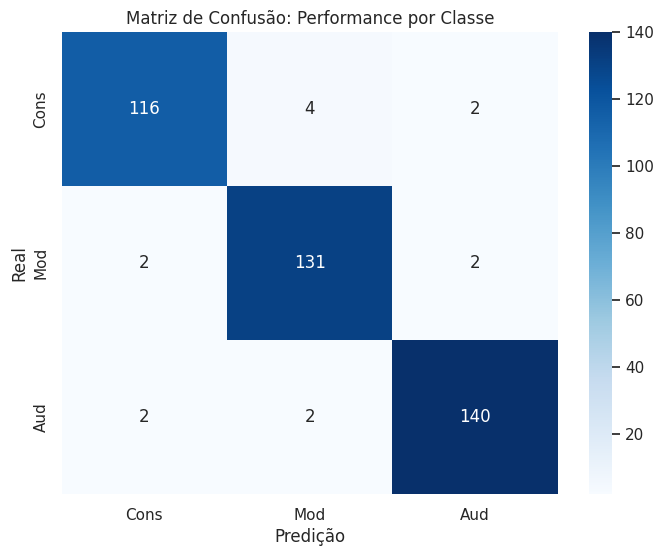

In [ ]:
# Avaliação: matriz de confusão por classe
from sklearn.metrics import confusion_matrix
import seaborn as sns

modelo.eval()
y_pred, y_true = [], []
with torch.no_grad():
    for X_test, y_test in test_loader:
        outputs = modelo(X_test)
        _, preds = torch.max(outputs, 1)
        y_pred.extend(preds.numpy())
        y_true.extend(y_test.numpy())

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Cons', 'Mod', 'Aud'], yticklabels=['Cons', 'Mod', 'Aud'])
plt.title('Matriz de Confusão: Performance por Classe')
plt.xlabel('Predição')
plt.ylabel('Real')
plt.show()

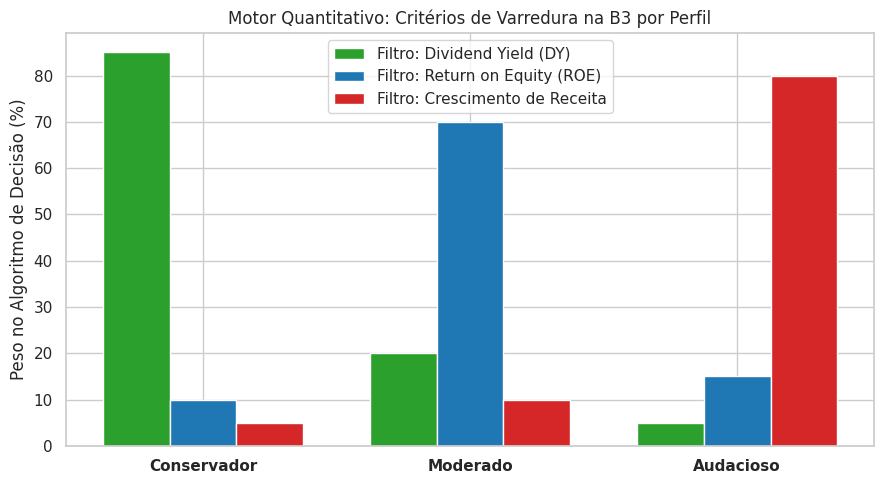

In [ ]:
# Visualização: pesos do motor quantitativo
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

sns.set_theme(style="whitegrid")

perfis = ['Conservador', 'Moderado', 'Audacioso']
peso_dy = [85, 20, 5]
peso_roe = [10, 70, 15]
peso_cresc = [5, 10, 80]

x = np.arange(len(perfis))
width = 0.25

fig, ax = plt.subplots(figsize=(9, 5))
rects1 = ax.bar(x - width, peso_dy, width, label='Filtro: Dividend Yield (DY)', color='#2ca02c')
rects2 = ax.bar(x, peso_roe, width, label='Filtro: Return on Equity (ROE)', color='#1f77b4')
rects3 = ax.bar(x + width, peso_cresc, width, label='Filtro: Crescimento de Receita', color='#d62728')

ax.set_ylabel('Peso no Algoritmo de Decisão (%)')
ax.set_title('Motor Quantitativo: Critérios de Varredura na B3 por Perfil')
ax.set_xticks(x)
ax.set_xticklabels(perfis, fontweight='bold')
ax.legend()

plt.tight_layout()
plt.show()